In [1]:
import os
import json
import random
import shutil
import re
import math
import time
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from matplotlib.animation import FuncAnimation 
import multiprocessing as mp

HOME = "/home/michal/slrm/gen4"
SAVE_DATA_LOCATION = "/home/michal/slrm/gen4"
if os.getenv("PLG_GROUPS_STORAGE"):
    HOME = "/net/people/plgrid/plgmichalgodek/workspace/ai-proton-simulations/gen4"
    SAVE_DATA_LOCATION =  os.environ["PLG_GROUPS_STORAGE"] + "/plggccbmc/mgodek/gen4"
os.chdir(HOME)

In [2]:
BATCH_NUM = 5

reg = re.compile(r"^_\d+$")
count_simulations = 0
for file_name in os.listdir(Path(SAVE_DATA_LOCATION,f"batch{BATCH_NUM}")):
    # print(file_name)
    if reg.match(file_name):
        count_simulations += 1


SIMULATIONS_TO_RUN = count_simulations
print(f"SIMULATIONS_TO_RUN: {SIMULATIONS_TO_RUN}")
print(f"BATCH_NUM: {BATCH_NUM}")


SIMULATIONS_TO_RUN: 23
BATCH_NUM: 5


In [3]:
import os

dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_" + "{run_num}"
param_files = []

for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    param_files.append(os.path.join(sim_dir,"input_params.txt"))

data_x = []

def open_energy(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
        energy = data.get("energy")

    return float(energy)

with mp.Pool() as pool:
    data_x = pool.map(open_energy, param_files, chunksize=1)

seeds_per_energy = 0
for i,x in enumerate(data_x):
    if float(x) == data_x[0]:
        seeds_per_energy += 1
    else:
        break

print(seeds_per_energy)

1


In [4]:
dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_"+"{run_num}"

z_profiles_to_convert = []
peaks_to_convert = []
print(f"looking for {SIMULATIONS_TO_RUN} directories")
for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    z_profiles_to_convert.append(Path(sim_dir,"output","z_profile.bdo"))
    peaks_to_convert.append(Path(sim_dir,"output","peak.bdo"))




looking for 23 directories


In [5]:
from pymchelper.input_output import fromfile
from matplotlib import pyplot as plt
import time


start = time.time()


def load_data(filename_tuple):
    filedata_z_profile, filedata_peak = fromfile(filename_tuple[0]), fromfile(filename_tuple[1])

    return filedata_z_profile, filedata_peak


with mp.Pool() as pool:
    results = pool.map(load_data, zip(z_profiles_to_convert, peaks_to_convert), chunksize=1)

import numpy as np
data_z_dose = np.array([dataset.pages[0].data_raw for dataset in [res[0] for res in results]])
data_z_fluence_protons = np.array([dataset.pages[1].data_raw for dataset in [res[0] for res in results]])
# data_z_dlet_protons = np.array([dataset.pages[4].data_raw for dataset in [res[0] for res in results]])
# data_r_dose = np.array([dataset.pages[0].data_raw for dataset in [res[1] for res in results]])
# plt.plot(arr)
print(len(data_z_dose), data_z_dose[0].shape)
print(len(data_z_fluence_protons), data_z_fluence_protons[0].shape)
# print(len(data_dlet_protons), data_dlet_protons[0].shape)
# print(len(data_r_dose), data_r_dose.shape)
print(f"time: {time.time()-start}")


23 (400,)
23 (400,)
time: 0.40908288955688477


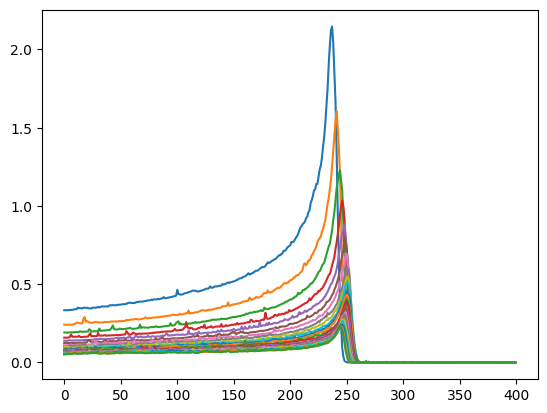

In [6]:
for i in range(len(data_z_dose)):
    plt.plot(data_z_dose[i])
plt.show()


In [19]:
with open(Path(HOME, f"batch{BATCH_NUM}", "batch_params"), "r") as batch_param:
    batch_params = json.load(batch_param)

energies = batch_params["energies"]
print(energies)

[20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240]


In [20]:
lengths = []

EXPONENT = 1.77
ALPHA = 0.0035

for energy in energies:
    lengths.append(math.floor(1000*ALPHA*energy**EXPONENT)/1000)
print(lengths)

[0.702, 1.44, 2.397, 3.558, 4.913, 6.454, 8.175, 10.071, 12.135, 14.365, 16.757, 19.308, 22.014, 24.874, 27.884, 31.042, 34.347, 37.797, 41.389, 45.122, 48.995, 53.006, 57.153]


In [ ]:
import numpy as np
k_factor = 0.01 # Adjust this to change how fast the window grows with energy

extracted_doses = []
extracted_z = []

ranges = []

for i, E in enumerate(energies):
    # 1. Calculate spatial resolution (cm per bin) for this specific energy
    L = lengths[i]
    dz = L / 400.0
    
    # 2. Define the target width in cm (grows proportionally to energy)
    target_width_cm = k_factor * E
    
    # 3. Convert target width to number of array bins (half on each side of peak)
    half_bins = int((target_width_cm / dz) / 2)
    peak_idx = np.argmax(data_z_dose[i])
    
    # 4. Calculate safe slice boundaries to prevent out-of-bounds errors
    start_idx = max(0, peak_idx - half_bins)
    end_idx = min(400, peak_idx + half_bins + 1)
    peak_pos_cm = dz*peak_idx
    start_z = math.floor(1000*(peak_pos_cm - (0.15 * L)))/1000
    end_z = math.floor(1000*(peak_pos_cm + (0.05 * L)))/1000
    
    # Extract the dose array and calculate the corresponding z-coordinates
    peak_dose_segment = data_z_dose[i][start_idx:end_idx]
    z_positions = np.arange(start_idx, end_idx) * dz
    
    extracted_doses.append(peak_dose_segment)
    extracted_z.append(z_positions)


    # print(start_idx)
    # print(start_z)
    # print(end_z)
    ranges.append((start_z, end_z))

ranges

[(0.31, 0.451),
 (0.651, 0.939),
 (1.102, 1.582),
 (1.654, 2.366),
 (2.309, 3.291),
 (3.033, 4.324),
 (3.862, 5.497),
 (4.783, 6.797),
 (5.794, 8.221),
 (6.823, 9.696),
 (7.959, 11.31),
 (9.171, 13.032),
 (10.456, 14.859),
 (11.815, 16.789),
 (13.175, 18.751),
 (14.667, 20.875),
 (16.228, 23.098),
 (17.764, 25.323),
 (19.245, 27.523),
 (20.981, 30.006),
 (22.782, 32.581),
 (24.515, 35.116),
 (26.29, 37.72)]

In [29]:
with open(Path(HOME,"peak_ranges"),"w") as peak_ranges_file:
    for peak_range in ranges:
        peak_ranges_file.write(f"{peak_range[0]},{peak_range[1]}\n")